# Testing pose estimation

In [108]:
import torch

print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.9.1+cu126 12.6 True
NVIDIA GeForce RTX 4070 Laptop GPU


In [109]:
from pathlib import Path

import imageio.v3 as iio
from PIL import Image, ImageDraw
import numpy as np
from aitraf.utils import get_video_rotation_deg


RAW_EXPORT_PATH = Path("../data/labels.jsonl")
CLIPS_DIR = Path("../data/clips")
YOLO_WEIGHTS = Path("../models/yolo11n-pose.pt")
BOXES_DIR = Path("../data/boxes")
POSES_DIR = Path("../data/poses")


CLIP_INDEX = 3
FRAME_INDEX = 70

#### Load video

In [110]:
clip_path = sorted(CLIPS_DIR.iterdir())[CLIP_INDEX]
clip_path

PosixPath('../data/clips/25-10-31 19-46-26 5688-00.00.46.631-00.00.52.733-seg04.mp4')

In [111]:
frames = [f for f in iio.imiter(clip_path)]
frame = frames[FRAME_INDEX]
frame = np.rot90(frame, k=get_video_rotation_deg(clip_path) // 90)

In [112]:
box_path = BOXES_DIR / (clip_path.stem + ".npz")
pose_path = POSES_DIR / (clip_path.stem + ".npz")

In [113]:
boxes_data = np.load(box_path, allow_pickle=True)
box = boxes_data["boxes"][FRAME_INDEX]

In [114]:
poses_data = np.load(pose_path, allow_pickle=True)
pose = poses_data["keypoints"][FRAME_INDEX][0]

In [115]:
pose

array([[   0.093167,     0.46881],
       [   0.091619,     0.46665],
       [   0.091331,     0.46643],
       [   0.070541,     0.46759],
       [   0.090502,     0.46759],
       [   0.055386,     0.48062],
       [    0.10118,     0.47957],
       [   0.036635,     0.49647],
       [    0.12975,     0.49334],
       [    0.02891,     0.50633],
       [    0.13816,     0.50464],
       [    0.05905,     0.51193],
       [   0.088046,      0.5114],
       [   0.065266,     0.53602],
       [   0.091717,     0.53527],
       [   0.060918,      0.5593],
       [   0.084667,     0.55856]], dtype=float32)

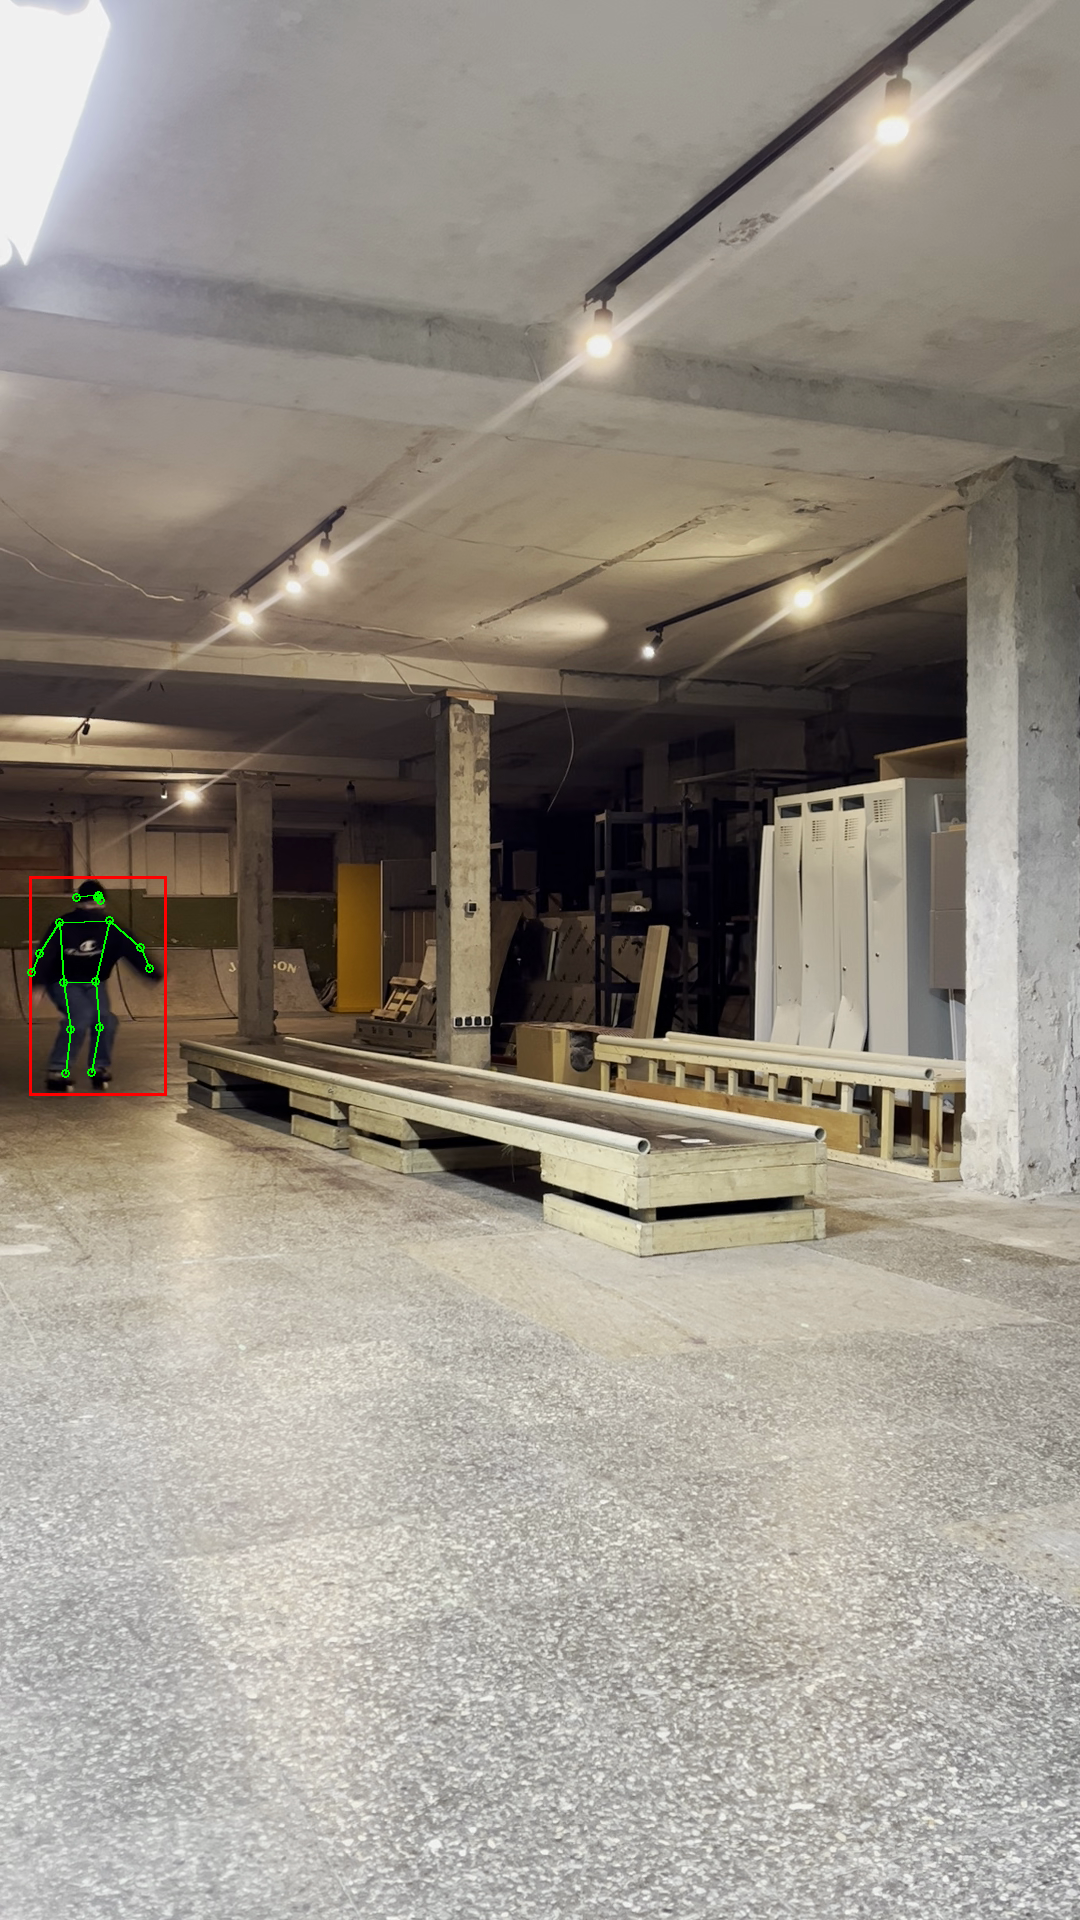

In [117]:
h, w = frame.shape[:2]

img = Image.fromarray(frame)
draw = ImageDraw.Draw(img)

for x1, y1, x2, y2 in box:
    x1 *= w
    x2 *= w
    y1 *= h
    y2 *= h

    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

r = 4
for kp in pose:
    x, y = kp[:2]
    x *= w
    y *= h
    draw.ellipse([x - r, y - r, x + r, y + r], outline="lime", width=2)

skeleton = [
    (0, 1),
    (0, 2),
    (1, 3),
    (2, 4),  # face
    (5, 6),  # shoulders
    (5, 7),
    (7, 9),  # left arm
    (6, 8),
    (8, 10),  # right arm
    (11, 12),  # hips
    (5, 11),
    (6, 12),  # torso
    (11, 13),
    (13, 15),  # left leg
    (12, 14),
    (14, 16),  # right leg
]


for a, b in skeleton:
    x1, y1 = pose[a] * [w, h]
    x2, y2 = pose[b] * [w, h]
    draw.line([x1, y1, x2, y2], fill="lime", width=2)


img = img.resize((w, h))
img.show()